## Setup

In [51]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cmocean
import matplotlib

plt.rcParams['figure.dpi'] = 300
matplotlib.rcParams["font.family"]      = "DejaVu Sans"
matplotlib.rcParams["figure.facecolor"] = "white"
matplotlib.rcParams["axes.facecolor"]   = "white"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Load Pretrained Models

In [52]:
from models.unet.default import Unet

def load_model(n_circles: int, epoch: int = 90) -> torch.nn.Module:
    ckpt = f"../outputs/fm_unet/n{n_circles}/checkpoints/epoch_{epoch:04d}.pt"
    model = Unet(ch=16, ch_mul=[1, 2, 4], att_channels=[0, 0, 1], groups=8, dropout=0.0).to(device)
    state = torch.load(ckpt, map_location=device, weights_only=True)
    new_state = {k.replace("module._orig_mod.", ""): v
                 for k, v in state.items() if k != "n_averaged"}
    model.load_state_dict(new_state)
    model.eval()
    print(f"  n={n_circles} loaded from {ckpt}")
    return model

models = {n: load_model(n) for n in [1, 2, 3, 4]}


def euler_integrate(model, x0, n_steps=200):
    """Forward Euler integration of the velocity field from t=0 to t=1."""
    dt = 1.0 / n_steps
    x = x0
    for i in range(n_steps):
        t = torch.full((x.shape[0],), i * dt, device=x.device)
        x = x + dt * model(x, t)
    return x


  n=1 loaded from ../outputs/fm_unet/n1/checkpoints/epoch_0090.pt
  n=2 loaded from ../outputs/fm_unet/n2/checkpoints/epoch_0090.pt
  n=3 loaded from ../outputs/fm_unet/n3/checkpoints/epoch_0090.pt
  n=4 loaded from ../outputs/fm_unet/n4/checkpoints/epoch_0090.pt


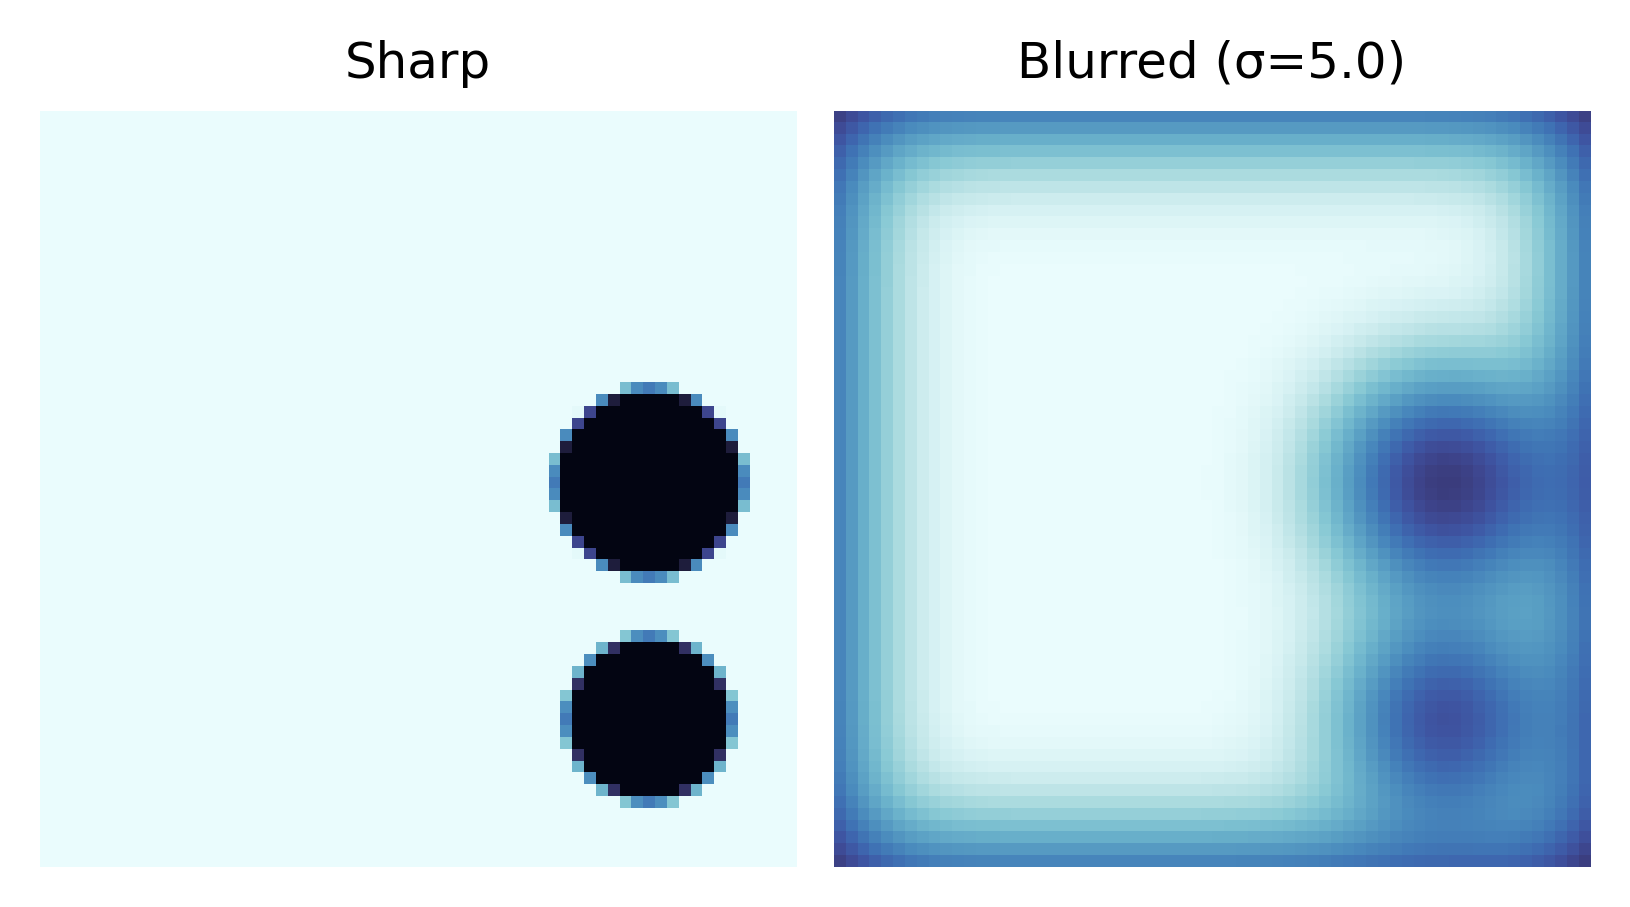

In [53]:
BLUR_SIGMA = 5.0   # σ=2 keeps enough frequencies for D-Flow to recover structure.

def make_blur(sigma: float, device):
    ks = int(6 * sigma + 1)
    ks = ks if ks % 2 == 1 else ks + 1
    half = ks // 2
    coords = torch.arange(ks, dtype=torch.float32) - half
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = (g / g.sum()).to(device)

    conv_x = torch.nn.Conv2d(1, 1, kernel_size=(1, ks), padding=(0, half), bias=False).to(device)
    conv_y = torch.nn.Conv2d(1, 1, kernel_size=(ks, 1), padding=(half, 0), bias=False).to(device)
    with torch.no_grad():
        conv_x.weight.copy_(g.view(1, 1, 1, ks))
        conv_y.weight.copy_(g.view(1, 1, ks, 1))
    for p in (*conv_x.parameters(), *conv_y.parameters()):
        p.requires_grad_(False)

    def H(x: torch.Tensor) -> torch.Tensor:
        return conv_y(conv_x(x))
    return H

H = make_blur(BLUR_SIGMA, device)

splits = torch.load("../data/circles-64-n2.pt", weights_only=True)
sample = splits["test"][0].unsqueeze(0).to(device)
blurred = H(sample)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 4), facecolor="white",
                                gridspec_kw={"wspace": 0.05}, dpi=400)
for ax, img, title in [(ax1, sample, "Sharp"), (ax2, blurred, f"Blurred (σ={BLUR_SIGMA})")]:
    ax.imshow(img.squeeze().cpu().numpy(), cmap=cmocean.cm.ice, vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
plt.show()


$$\mathcal{L} = ||\text{H}(x_0) - y_{\text{obs}}||^2$$

In [54]:
def mse_cost(x, y):
    return (x - y).pow(2).mean()

## D-Flow Optimisation (Adam)

## D-Flow: n = 1

Converges quickly — can use a larger learning rate.

In [55]:
torch.manual_seed(1234)
results = {}

# ── n=1 hyperparameters ──────────────────────────────────────────────────────
N1_EULER_OPT  = 3
N1_EULER_REND = 200
N1_LR         = 2e-2
N1_BETAS      = (0.9, 0.999)
N1_STEPS      = 10000
N1_ETA_MIN    = 1e-5
N1_STOP_LOSS  = 0.0000001
LOG_EVERY     = 100

model = models[1]
x0_gt = torch.randn(1, 1, 64, 64, device=device)

with torch.no_grad():
    y_gt  = euler_integrate(model, x0_gt, n_steps=N1_EULER_REND).clamp(0, 1)
    y_obs = H(y_gt)

x0 = torch.randn(1, 1, 64, 64, device=device, requires_grad=True)
optimizer = torch.optim.Adam([x0], lr=N1_LR, betas=N1_BETAS)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N1_STEPS, eta_min=N1_ETA_MIN)

best_loss = float("inf")
best_x0   = x0.detach().clone()
best_step = -1

print("n=1:")
for step in range(N1_STEPS):
    optimizer.zero_grad()
    y_pred = euler_integrate(model, x0, n_steps=N1_EULER_OPT)
    loss = mse_cost(H(y_pred), y_obs)
    loss.backward()
    torch.nn.utils.clip_grad_norm_([x0], max_norm=1.0)
    optimizer.step()
    scheduler.step()

    cur = loss.item()
    if cur < best_loss:
        best_loss = cur
        best_x0   = x0.detach().clone()
        best_step = step

    if step % LOG_EVERY == 0:
        grad_norm = x0.grad.norm().item() if x0.grad is not None else 0.0
        print(f"  [step {step:4d}] loss={cur:.7f}  best={best_loss:.7f}  |grad|={grad_norm:.7f}")

    if cur < N1_STOP_LOSS:
        print(f"  [step {step:4d}] converged — loss={cur:.7f}")
        break

print(f"  best loss={best_loss:.7f} at step {best_step}")

with torch.no_grad():
    y_hat = euler_integrate(model, best_x0, n_steps=N1_EULER_REND).clamp(0, 1)

results[1] = {
    "y_gt": y_gt.cpu(), "y_obs": y_obs.cpu(),
    "y_hat": y_hat.cpu(), "err": (y_hat - y_gt).cpu(),
    "best_loss": best_loss, "best_step": best_step,
}

n=1:
  [step    0] loss=0.013942  best=0.013942  |grad|=0.000392
  [step  100] loss=0.001418  best=0.001308  |grad|=0.004651
  [step  200] loss=0.000033  best=0.000033  |grad|=0.000055
  [step  300] loss=0.000016  best=0.000016  |grad|=0.000007
  [step  400] loss=0.000013  best=0.000013  |grad|=0.000008
  [step  500] loss=0.000011  best=0.000011  |grad|=0.000006
  [step  600] loss=0.000010  best=0.000010  |grad|=0.000004
  [step  700] loss=0.000009  best=0.000009  |grad|=0.000004
  [step  800] loss=0.000007  best=0.000007  |grad|=0.000003
  [step  900] loss=0.000007  best=0.000007  |grad|=0.000006
  [step 1000] loss=0.000006  best=0.000006  |grad|=0.000002
  [step 1100] loss=0.000005  best=0.000005  |grad|=0.000002
  [step 1200] loss=0.000005  best=0.000005  |grad|=0.000003
  [step 1300] loss=0.000004  best=0.000004  |grad|=0.000001
  [step 1400] loss=0.000004  best=0.000004  |grad|=0.000002
  [step 1500] loss=0.000003  best=0.000003  |grad|=0.000004
  [step 1600] loss=0.000003  best=0

In [56]:
# ── n=2 hyperparameters ──────────────────────────────────────────────────────
N2_EULER_OPT  = 3
N2_EULER_REND = 200
N2_LR         = 5e-2
N2_BETAS      = (0.9, 0.999)
N2_STEPS      = 10000
N2_ETA_MIN    = 1e-5
N2_STOP_LOSS  = 0.0000001
LOG_EVERY     = 100

model = models[2]
x0_gt = torch.randn(1, 1, 64, 64, device=device)

with torch.no_grad():
    y_gt  = euler_integrate(model, x0_gt, n_steps=N2_EULER_REND).clamp(0, 1)
    y_obs = H(y_gt)

x0 = torch.randn(1, 1, 64, 64, device=device, requires_grad=True)
optimizer = torch.optim.Adam([x0], lr=N2_LR, betas=N2_BETAS)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N2_STEPS, eta_min=N2_ETA_MIN)

best_loss = float("inf")
best_x0   = x0.detach().clone()
best_step = -1

print("n=2:")
for step in range(N2_STEPS):
    optimizer.zero_grad()
    y_pred = euler_integrate(model, x0, n_steps=N2_EULER_OPT)
    loss = mse_cost(H(y_pred), y_obs)
    loss.backward()
    torch.nn.utils.clip_grad_norm_([x0], max_norm=1.0)
    optimizer.step()
    scheduler.step()

    cur = loss.item()
    if cur < best_loss:
        best_loss = cur
        best_x0   = x0.detach().clone()
        best_step = step

    if step % LOG_EVERY == 0:
        grad_norm = x0.grad.norm().item() if x0.grad is not None else 0.0
        print(f"  [step {step:4d}] loss={cur:.7f}  best={best_loss:.7f}  |grad|={grad_norm:.7f}")

    if cur < N2_STOP_LOSS:
        print(f"  [step {step:4d}] converged — loss={cur:.7f}")
        break

print(f"  best loss={best_loss:.7f} at step {best_step}")

with torch.no_grad():
    y_hat = euler_integrate(model, best_x0, n_steps=N2_EULER_REND).clamp(0, 1)

results[2] = {
    "y_gt": y_gt.cpu(), "y_obs": y_obs.cpu(),
    "y_hat": y_hat.cpu(), "err": (y_hat - y_gt).cpu(),
    "best_loss": best_loss, "best_step": best_step,
}

n=2:
  [step    0] loss=0.0160848  best=0.0160848  |grad|=0.0006304
  [step  100] loss=0.0122654  best=0.0122654  |grad|=0.0000862
  [step  200] loss=0.0079708  best=0.0079708  |grad|=0.0000983
  [step  300] loss=0.0066454  best=0.0062700  |grad|=0.0000755
  [step  400] loss=0.0055350  best=0.0055350  |grad|=0.0002840
  [step  500] loss=0.0048630  best=0.0048630  |grad|=0.0001096
  [step  600] loss=0.0031765  best=0.0031765  |grad|=0.0001092
  [step  700] loss=0.0015414  best=0.0015414  |grad|=0.0000733
  [step  800] loss=0.0007373  best=0.0007373  |grad|=0.0004433
  [step  900] loss=0.0005497  best=0.0005497  |grad|=0.0001227
  [step 1000] loss=0.0003324  best=0.0003324  |grad|=0.0000921
  [step 1100] loss=0.0003462  best=0.0001884  |grad|=0.0000135
  [step 1200] loss=0.0001272  best=0.0001272  |grad|=0.0000239
  [step 1300] loss=0.0002299  best=0.0000794  |grad|=0.0000140
  [step 1400] loss=0.0001330  best=0.0000794  |grad|=0.0000101
  [step 1500] loss=0.0001197  best=0.0000794  |gra

In [57]:
# ── n=3 hyperparameters ──────────────────────────────────────────────────────
N3_EULER_OPT  = 3
N3_EULER_REND = 200
N3_LR         = 9e-2
N3_BETAS      = (0.9, 0.999)
N3_STEPS      = 20000
N3_ETA_MIN    = 1e-5
N3_STOP_LOSS  = 0.0000001
LOG_EVERY     = 100

model = models[3]
x0_gt = torch.randn(1, 1, 64, 64, device=device)

with torch.no_grad():
    y_gt  = euler_integrate(model, x0_gt, n_steps=N3_EULER_REND).clamp(0, 1)
    y_obs = H(y_gt)

x0 = torch.randn(1, 1, 64, 64, device=device, requires_grad=True)
optimizer = torch.optim.Adam([x0], lr=N3_LR, betas=N3_BETAS)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N3_STEPS, eta_min=N3_ETA_MIN)

best_loss = float("inf")
best_x0   = x0.detach().clone()
best_step = -1

print("n=3:")
for step in range(N3_STEPS):
    optimizer.zero_grad()
    y_pred = euler_integrate(model, x0, n_steps=N3_EULER_OPT)
    loss = mse_cost(H(y_pred), y_obs)
    loss.backward()
    torch.nn.utils.clip_grad_norm_([x0], max_norm=1.0)
    optimizer.step()
    scheduler.step()

    cur = loss.item()
    if cur < best_loss:
        best_loss = cur
        best_x0   = x0.detach().clone()
        best_step = step

    if step % LOG_EVERY == 0:
        grad_norm = x0.grad.norm().item() if x0.grad is not None else 0.0
        print(f"  [step {step:4d}] loss={cur:.7f}  best={best_loss:.7f}  |grad|={grad_norm:.7f}")

    if cur < N3_STOP_LOSS:
        print(f"  [step {step:4d}] converged — loss={cur:.7f}")
        break

print(f"  best loss={best_loss:.7f} at step {best_step}")

with torch.no_grad():
    y_hat = euler_integrate(model, best_x0, n_steps=N3_EULER_REND).clamp(0, 1)

results[3] = {
    "y_gt": y_gt.cpu(), "y_obs": y_obs.cpu(),
    "y_hat": y_hat.cpu(), "err": (y_hat - y_gt).cpu(),
    "best_loss": best_loss, "best_step": best_step,
}

n=3:
  [step    0] loss=0.0220614  best=0.0220614  |grad|=0.0400855
  [step  100] loss=0.0069039  best=0.0069039  |grad|=0.0000415
  [step  200] loss=0.0042362  best=0.0042344  |grad|=0.0000514
  [step  300] loss=0.0027904  best=0.0027505  |grad|=0.0000521
  [step  400] loss=0.0022396  best=0.0022396  |grad|=0.0000279
  [step  500] loss=0.0014541  best=0.0014541  |grad|=0.0000220
  [step  600] loss=0.0012839  best=0.0012839  |grad|=0.0000820
  [step  700] loss=0.0012348  best=0.0010521  |grad|=0.0000190
  [step  800] loss=0.0011291  best=0.0010521  |grad|=0.0001525
  [step  900] loss=0.0068654  best=0.0010521  |grad|=0.0000393
  [step 1000] loss=0.0058113  best=0.0010521  |grad|=0.0000341
  [step 1100] loss=0.0054748  best=0.0010521  |grad|=0.0000225
  [step 1200] loss=0.0053438  best=0.0010521  |grad|=0.0000172
  [step 1300] loss=0.0052570  best=0.0010521  |grad|=0.0000136
  [step 1400] loss=0.0330942  best=0.0010521  |grad|=0.0018869
  [step 1500] loss=0.0050644  best=0.0010521  |gra

In [58]:
# ── n=4 hyperparameters ──────────────────────────────────────────────────────
N4_EULER_OPT  = 3
N4_EULER_REND = 200
N4_LR         = 9e-2
N4_BETAS      = (0.9, 0.999)
N4_STEPS      = 40000
N4_ETA_MIN    = 1e-5
N4_STOP_LOSS  = 0.0000001
LOG_EVERY     = 100

model = models[4]
x0_gt = torch.randn(1, 1, 64, 64, device=device)

with torch.no_grad():
    y_gt  = euler_integrate(model, x0_gt, n_steps=N4_EULER_REND).clamp(0, 1)
    y_obs = H(y_gt)

x0 = torch.randn(1, 1, 64, 64, device=device, requires_grad=True)
optimizer = torch.optim.Adam([x0], lr=N4_LR, betas=N4_BETAS)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N4_STEPS, eta_min=N4_ETA_MIN)

best_loss = float("inf")
best_x0   = x0.detach().clone()
best_step = -1

print("n=4:")
for step in range(N4_STEPS):
    optimizer.zero_grad()
    y_pred = euler_integrate(model, x0, n_steps=N4_EULER_OPT)
    loss = mse_cost(H(y_pred), y_obs)
    loss.backward()
    torch.nn.utils.clip_grad_norm_([x0], max_norm=1.0)
    optimizer.step()
    scheduler.step()

    cur = loss.item()
    if cur < best_loss:
        best_loss = cur
        best_x0   = x0.detach().clone()
        best_step = step

    if step % LOG_EVERY == 0:
        grad_norm = x0.grad.norm().item() if x0.grad is not None else 0.0
        print(f"  [step {step:4d}] loss={cur:.7f}  best={best_loss:.7f}  |grad|={grad_norm:.7f}")

    if cur < N4_STOP_LOSS:
        print(f"  [step {step:4d}] converged — loss={cur:.7f}")
        break

print(f"  best loss={best_loss:.7f} at step {best_step}")

with torch.no_grad():
    y_hat = euler_integrate(model, best_x0, n_steps=N4_EULER_REND).clamp(0, 1)

results[4] = {
    "y_gt": y_gt.cpu(), "y_obs": y_obs.cpu(),
    "y_hat": y_hat.cpu(), "err": (y_hat - y_gt).cpu(),
    "best_loss": best_loss, "best_step": best_step,
}

n=4:
  [step    0] loss=0.0180341  best=0.0180341  |grad|=0.0016706
  [step  100] loss=0.0193794  best=0.0178741  |grad|=0.0000631
  [step  200] loss=0.0089651  best=0.0075041  |grad|=0.0020226
  [step  300] loss=0.0067343  best=0.0067343  |grad|=0.0000537
  [step  400] loss=0.0063610  best=0.0063610  |grad|=0.0000554
  [step  500] loss=0.0059085  best=0.0059085  |grad|=0.0000486
  [step  600] loss=0.0056832  best=0.0054013  |grad|=0.0002210
  [step  700] loss=0.0044687  best=0.0044687  |grad|=0.0002701
  [step  800] loss=0.0043360  best=0.0038407  |grad|=0.0004184
  [step  900] loss=0.0019783  best=0.0019783  |grad|=0.0000334
  [step 1000] loss=0.0018210  best=0.0018210  |grad|=0.0000199
  [step 1100] loss=0.0204357  best=0.0017622  |grad|=0.0015203
  [step 1200] loss=0.0113367  best=0.0017622  |grad|=0.0002616
  [step 1300] loss=0.0084329  best=0.0017622  |grad|=0.0007938
  [step 1400] loss=0.0019984  best=0.0017622  |grad|=0.0000789
  [step 1500] loss=0.0008091  best=0.0008091  |gra

## Results

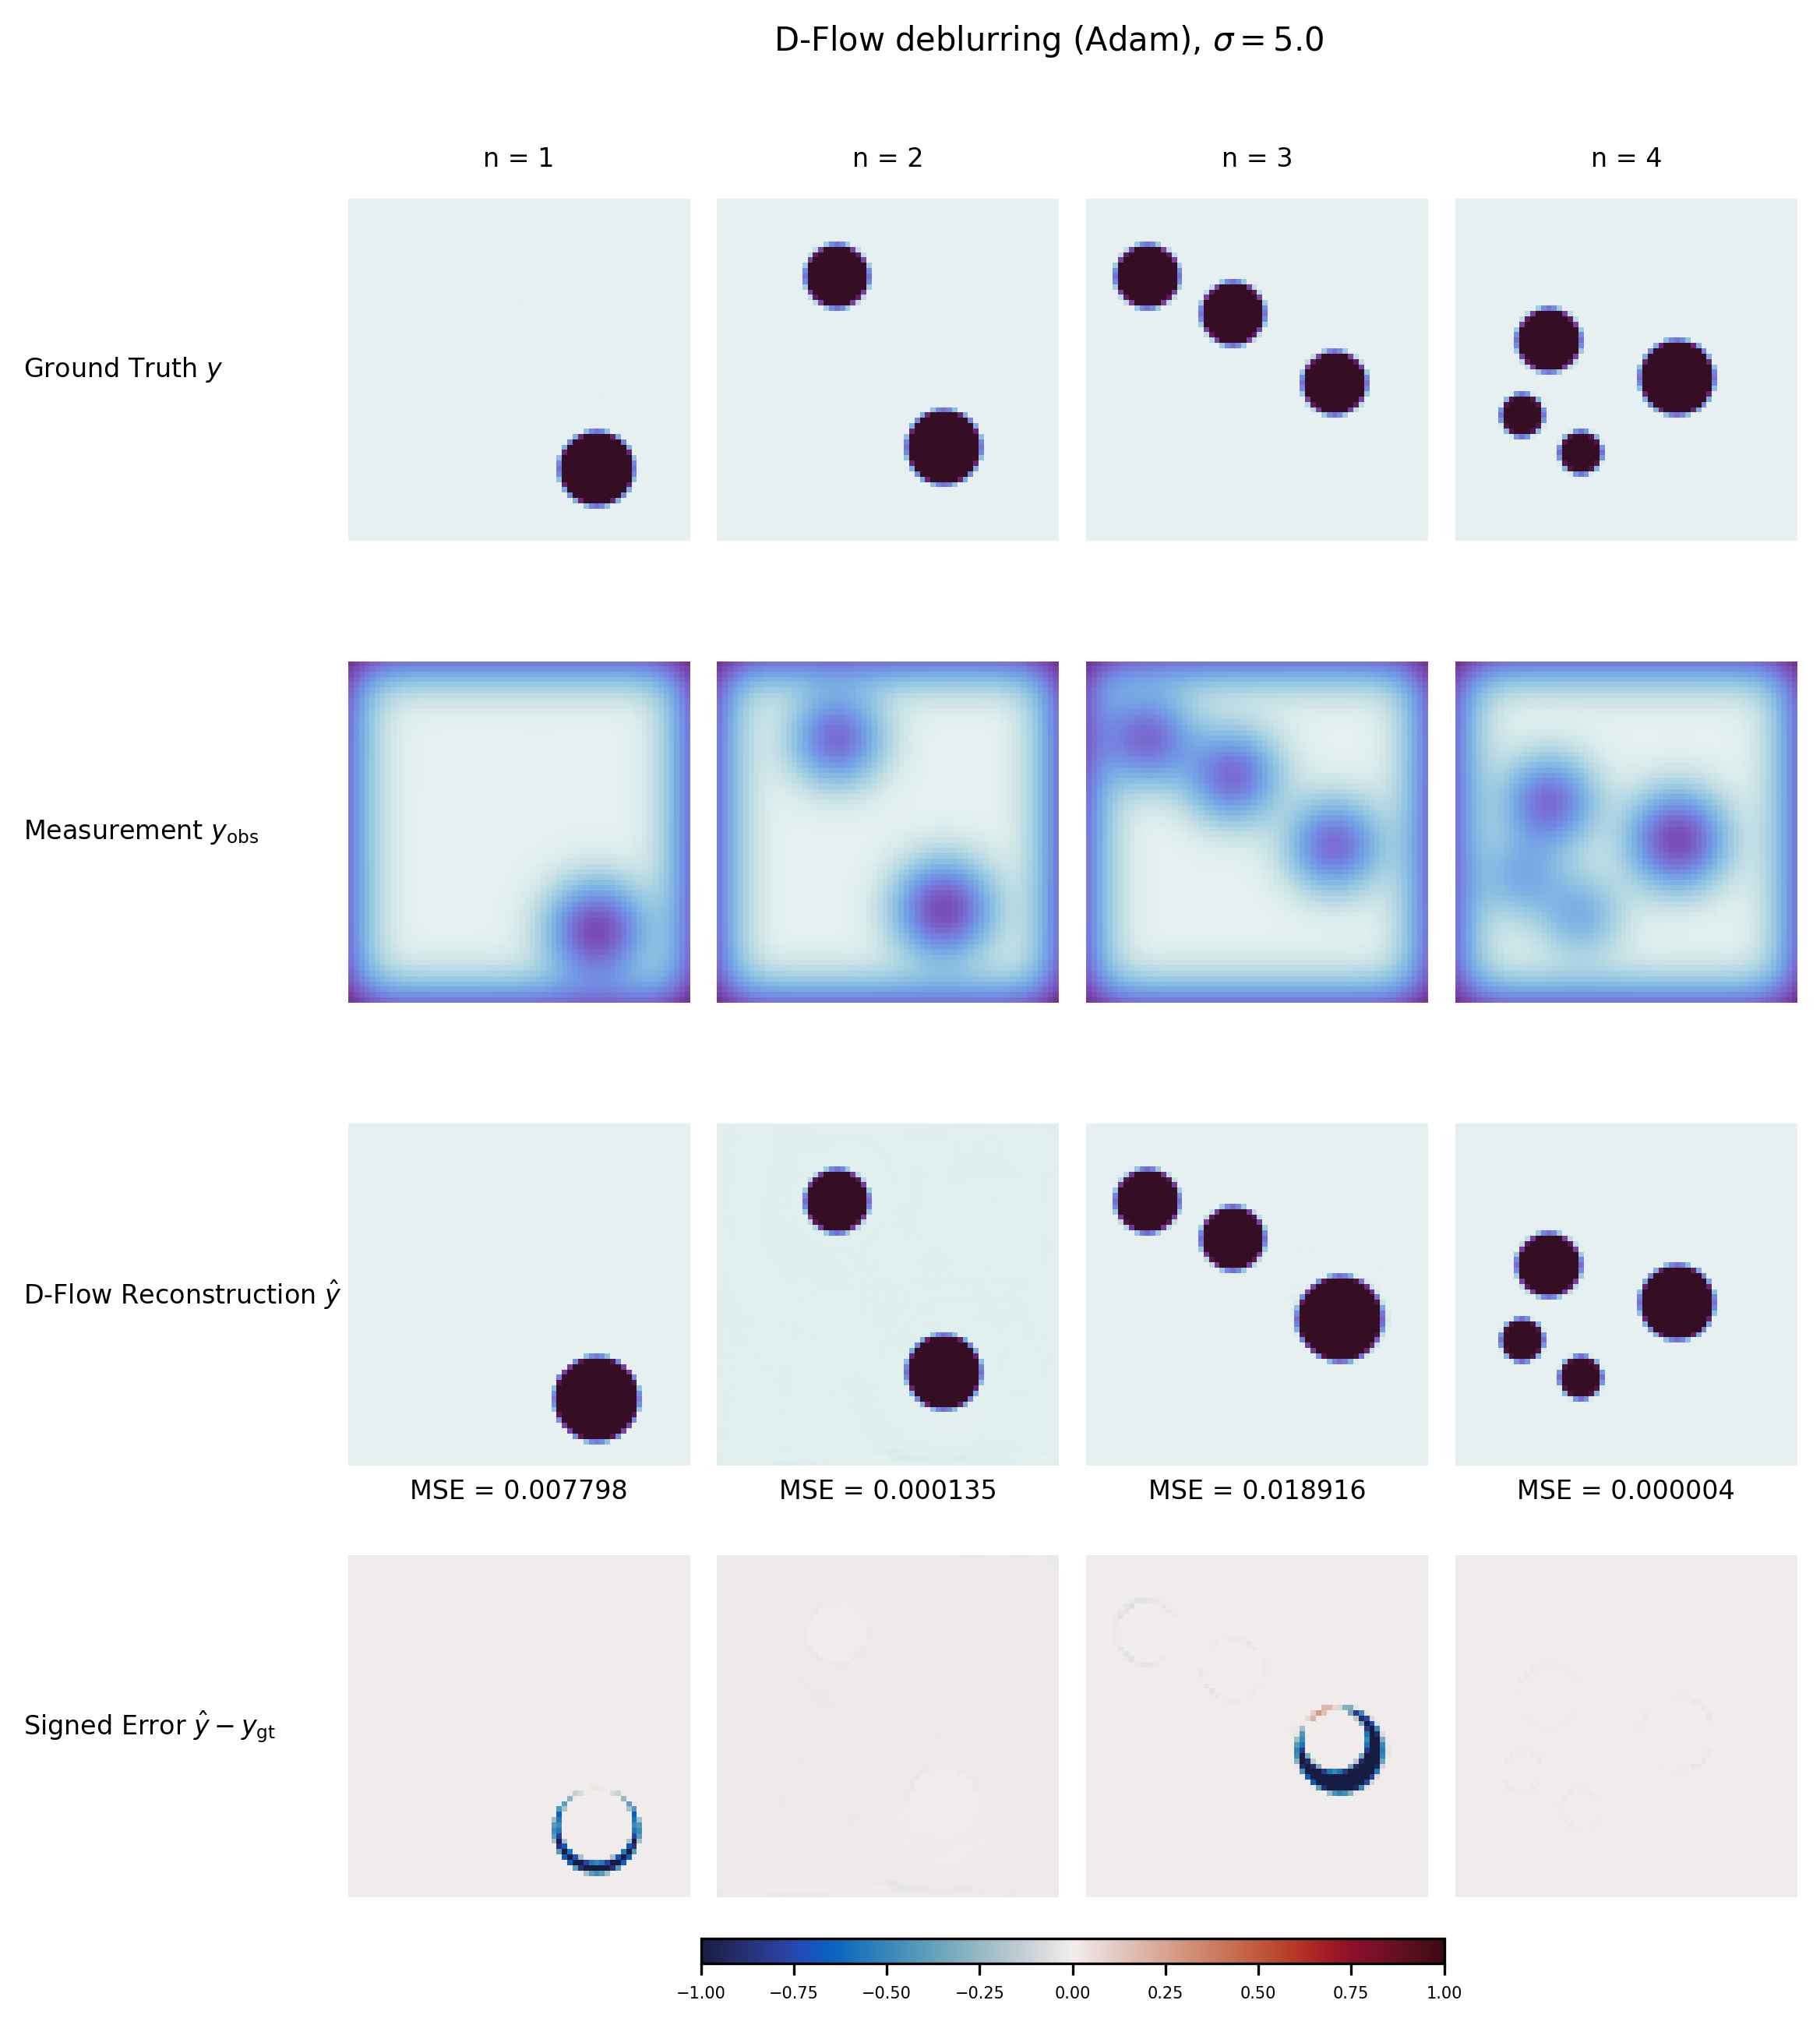

: 

In [ ]:
row_labels = [r"Ground Truth $x(1)$", r"Measurement $y_{\mathrm{obs}}$",
              r"D-Flow Reconstruction $\hat{y}$", r"Signed Error $\hat{x}(1) - x(1)$"]
ncols = 4
nrows = len(row_labels)

fig, axes = plt.subplots(nrows, ncols, figsize=(8, 10), facecolor="white",
                         gridspec_kw={"hspace": 0.12, "wspace": 0.08}, dpi=300)

for col, n in enumerate([1, 2, 3, 4]):
    res = results[n]
    mse = res["err"].pow(2).mean().item()

    for row, (img, cmap, vmin, vmax) in enumerate([
        (res["y_gt"],  cmocean.cm.dense_r, 0, 1),
        (res["y_obs"], cmocean.cm.dense_r, 0, 1),
        (res["y_hat"], cmocean.cm.dense_r, 0, 1),
        (res["err"],   cmocean.cm.balance, -1, 1),
    ]):
        ax = axes[row, col]
        im = ax.imshow(img.squeeze().numpy(), cmap=cmap, vmin=vmin, vmax=vmax,
                       interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)

    axes[0, col].set_title(f"n = {n}", fontsize=8, pad=10)
    axes[2, col].set_xlabel(f"MSE = {mse:.6f}", fontsize=8, labelpad=4)

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=8, rotation=0, labelpad=100,
                            va="center", ha="left")

cbar = fig.colorbar(im, ax=axes[3, :].tolist(), location="bottom",
                    fraction=0.06, pad=0.1, aspect=30)
cbar.ax.tick_params(labelsize=5)

fig.suptitle(rf"D-Flow deblurring (Adam), $\sigma = {BLUR_SIGMA}$", fontsize=10, y=0.94)
plt.show()

## Summary Table

In [60]:
print(f"{'n':>3}  {'MSE(y_hat, y_gt)':>18}")
print("-" * 24)
for n in [1, 2, 3, 4]:
    mse = results[n]["err"].pow(2).mean().item()
    print(f"{n:>3}  {mse:>18.6f}")

  n    MSE(y_hat, y_gt)
------------------------
  1            0.007798
  2            0.000135
  3            0.018916
  4            0.000004
